# [IAPR][iapr]: Lab 2 ‒  Object description


**Group ID:** xx

**Author 1 (sciper):** Student Name 1 (xxxxx)  
**Author 2 (sciper):** Student Name 2 (xxxxx)   
**Author 3 (sciper):** Student Name 3 (xxxxx)   

**Release date:** 18.03.2026  
**Due date:** 01.04.2026 (11:59 pm)


## Key Submission Guidelines:

- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`  
- **Only groups of three will be accepted**, except in exceptional circumstances.  
- **You are not allowed to use any libraries** other than those provided in this notebook.  
- **TAs must be able to run your code from start to finish without any issues.**  
- **Failure to follow these guidelines may result in point deductions** during grading.  


[iapr]: https://github.com/LTS5/iapr2025

In [1]:
# Check is at least python 3.9
import sys 
assert (sys.version_info.major >= 3) and (sys.version_info.minor >= 9)

In [2]:
# Install required packages
!pip install wget -q
!pip install numpy -q
!pip install matplotlib -q
!pip install scikit-image -q
!pip install scikit-learn -q
!pip install python-mnist -q
!pip install opencv-python -q

In [1]:
# Import main packages
from utils.lab_02_utils import *
from skimage.morphology import remove_small_objects, remove_small_holes, closing, disk, opening
from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops, find_contours

import cv2
import numpy as np

---
# Introduction

In this lab, we will work with the famous MNIST dataset. It is composed of thousands of images (size 28x28) that depict handwritten digits from 0 to 9. The code below will automatically download the data from the online repo. This lab aims to create discriminant features from handwritten digits using various approaches. 


Take a look at the data to get a better idea of what you will be working within this lab.

100% [..............................................................................] 28881 / 28881Data downloaded under folder: ..\data\data_lab_02
60000 Images and 60000 labels loaded


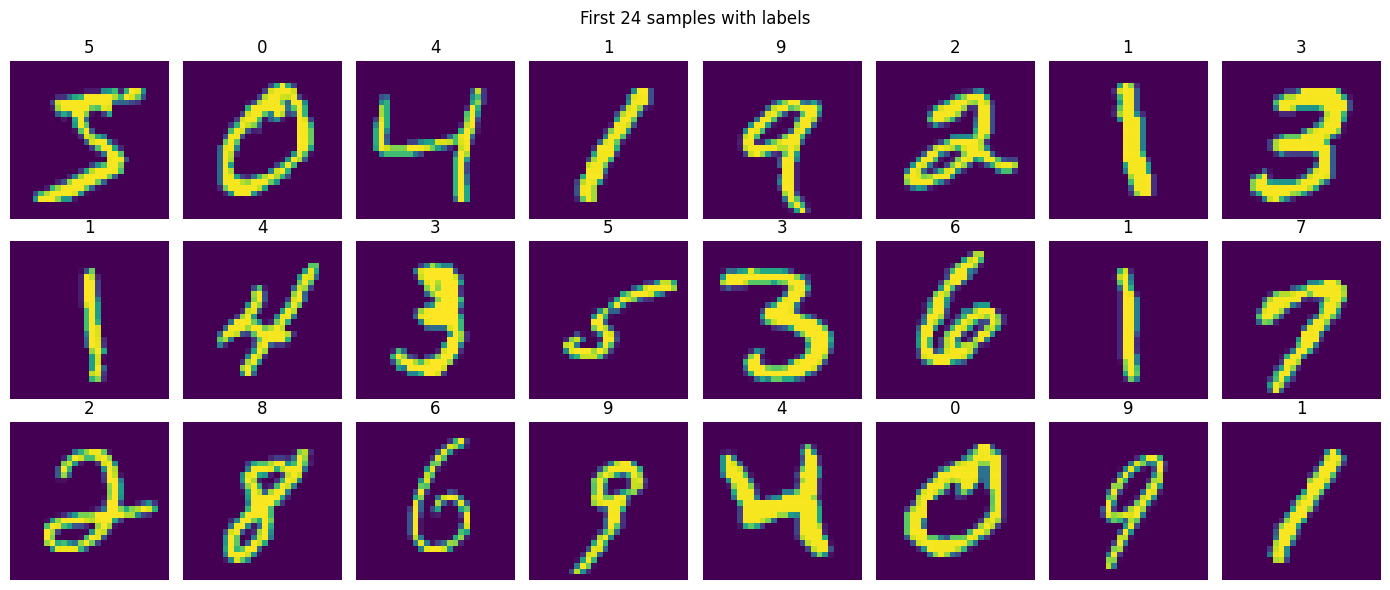

In [2]:
images, labels = load_lab02_data()

---
# Part 1 - Preprocessing [2 pts]


In this lab, we will create different feautre descriptors from digits. However, we will not use all images in the dataset. We will focus on the digits "0" and "5".

## 1.1 Selection (1 pt)

**Q1 (1 pt)** Your first task is to complete the function `extract_label` such that it selects from the input data only the images that are labeled as a given `target_label`. This function will be used to extract 0s and 5s from the data cohort. When running the code, the plots should only show you samples that are 0s (first plot) and 5s (second plot)

In [3]:
def extract_label(images: np.ndarray, labels: np.ndarray, target_label: int):
    """
    The function returns only the images that have target_label as labels.
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images - handwritten digits 
    labels: np.ndarray (N)
        List of labels associated with the input image
    target_label: int
        Selected target label

    Return
    ------
    img_extract: np.ndarray (M, 28, 28)
        Extracted images that have target_label as label (M should be lower than N).
    """

    n, d, _ = np.shape(images) 
    img_extract = np.zeros((30, d, d))
    
    # ------------------
    img_extract = images[labels == target_label]
    # ------------------
    
    return img_extract

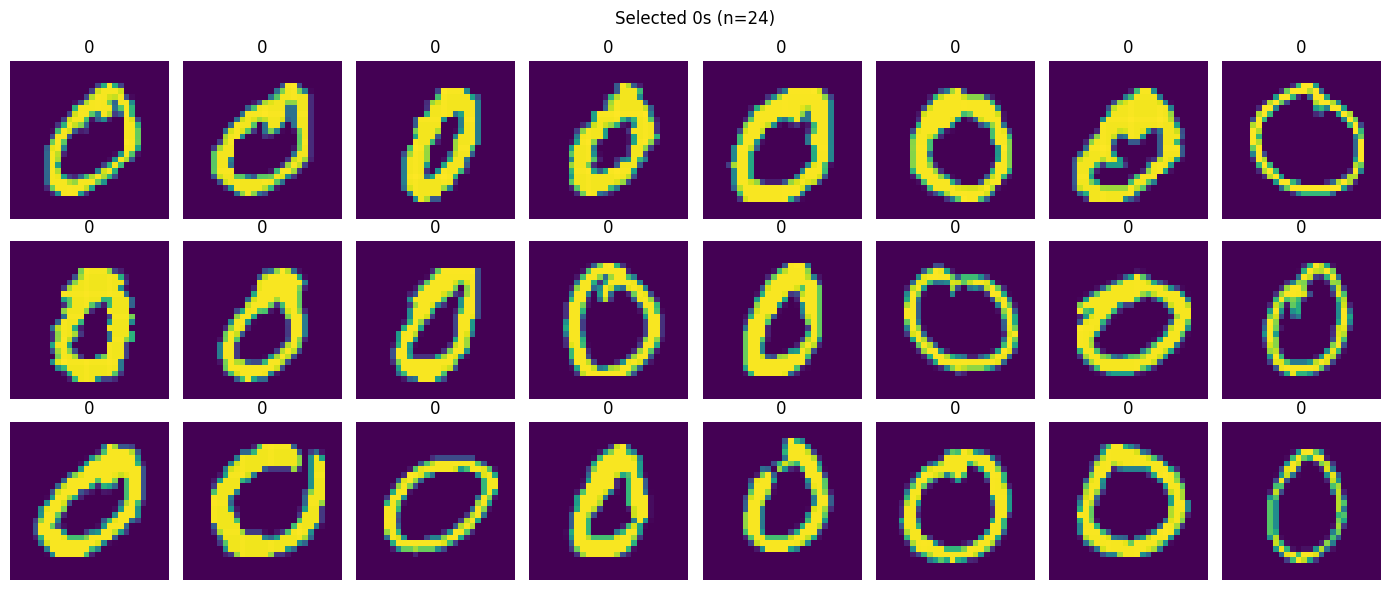

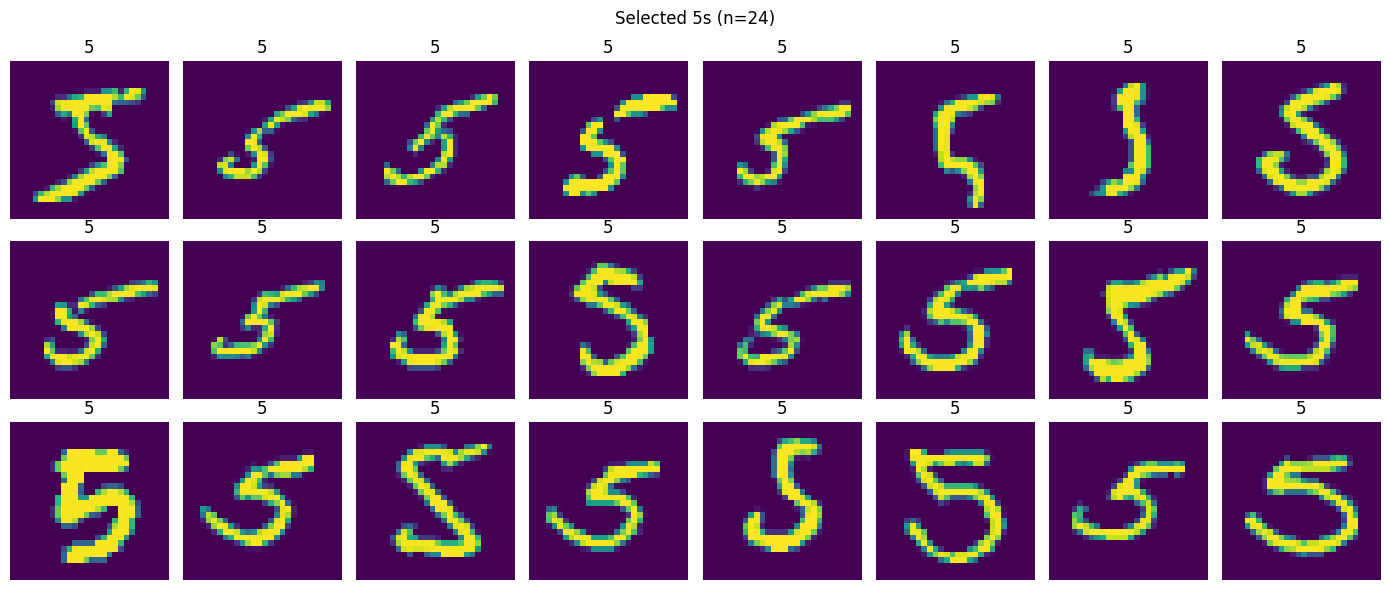

In [4]:
################################################################
############################ TEST ##############################
################################################################

images_a, images_b = test_1_1(extract_label, images, labels)

## 1.2 Preprocessing (1 pt)

Before computing the Fourier descriptors we need to preprocess the images.

* **Q1 (1 pt)**: Complete the function `preprocess` such that it cleans the input images. Take a look at the example images above and try to think what could be improved to allow better uniformity of the data. Take advantage of what you have learned in the previous lab.

In [5]:
def preprocess(images: np.ndarray):
    """
    Apply the processing step to images to achieve better data uniformity.
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images

    Return
    ------
    img_process: np.ndarray (N, 28, 28)
        Processed images.
    """

    # Get the shape of input data and set dummy values
    n, d, _ = np.shape(images) 
    img_process = np.zeros_like(images)
    
    # ------------------
    # Your code here ... 
    # ------------------
    # The preprocessing: Binarization, remove isolated pixels
    # filling holes/small gaps and smoothing boundaries.
    from skimage.filters import threshold_otsu
    from skimage.morphology import remove_small_objects, closing, dilation, erosion, square, rectangle, diamond,disk
    import warnings
    warnings.filterwarnings('ignore')
    for i in range(n):
        img = images[i]

        thresh = threshold_otsu(img)
        binary = img > thresh

        cleaned = remove_small_objects(binary, min_size=3)
        selem = disk(1)        
        closed = closing(cleaned, selem)

        img_process[i] = closed.astype(np.uint8)

    return img_process

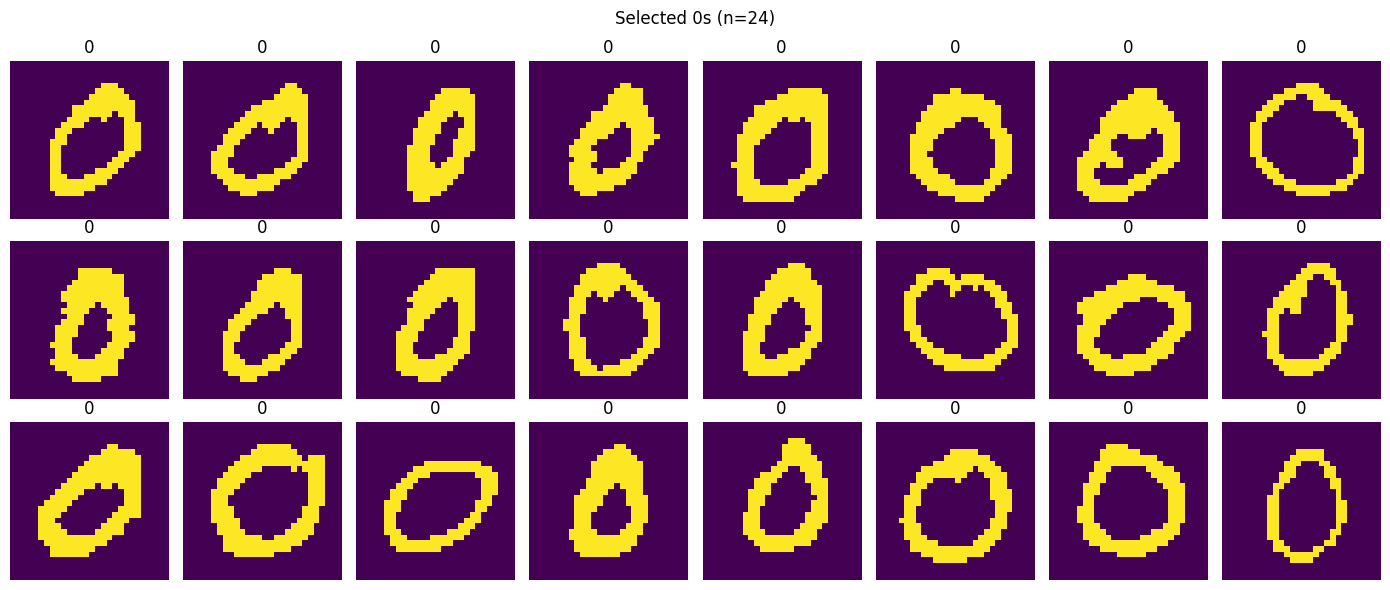

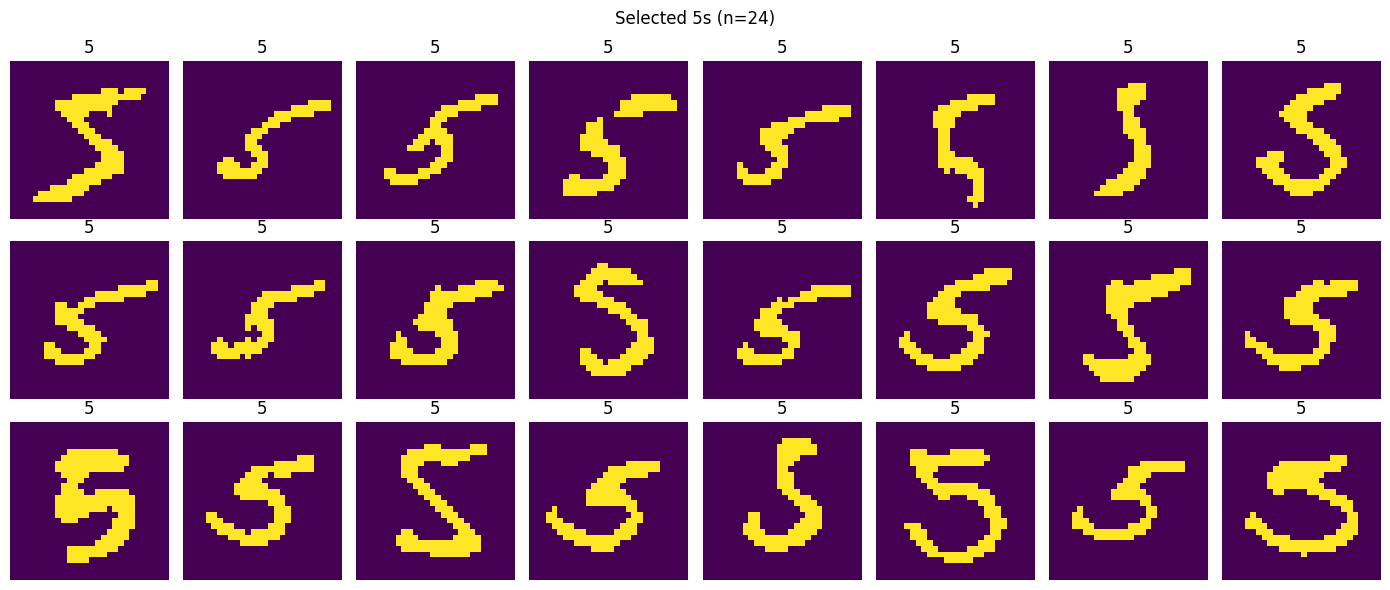

In [6]:
################################################################
############################ TEST ##############################
################################################################

images_p_a, images_p_b = test_1_2(preprocess, images_a, images_b)

---
# Part 2 - Fourier Descriptors [17 pts]


## 2.1. Get contour and descriptors (9 pts)

In this section, we will create Fourier descriptors from digits. The next step in our pipeline will be to detect the contours. To do so you can use existing algorithm available online such as `find_contours`([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.find_contours)) from skcit-image or `findContours` ([doc](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0)) from opencv. Pay attention to the coordinate system when using the contour detection function (is the first component x or y coordinate?).

* **Q1 (2 pts)**: Complete the function `find_contour` below such that it returns the contour estimations of the given images. The provided `display_samples` function will display the returned contours for a subset of images.

In [9]:
	
def find_contour(images: np.ndarray):
    """
    Find the contours for the set of images
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images to process

    Return
    ------
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    """

    # Get number of images to process
    N, _, _ = np.shape(images)
    # Fill in dummy values (fake points)
    contours = []

    # ------------------
    # Your code here ... 
    # ------------------
    for i in range(N):
        # find contours
        all_contours = find_contours(images[i], level = 0.5)    # level = 0.5 because binary

        if len(all_contours)>0:
            longest_contour = max(all_contours, key=len)
            # swap to x,y coordinates
            fixed_contour = longest_contour[:, [1, 0]] 
            contours.append(fixed_contour)
        else:
            # if there's no contour
            contours.append(np.array([[0,0], [1,1]]))
    
    
    return contours

1000


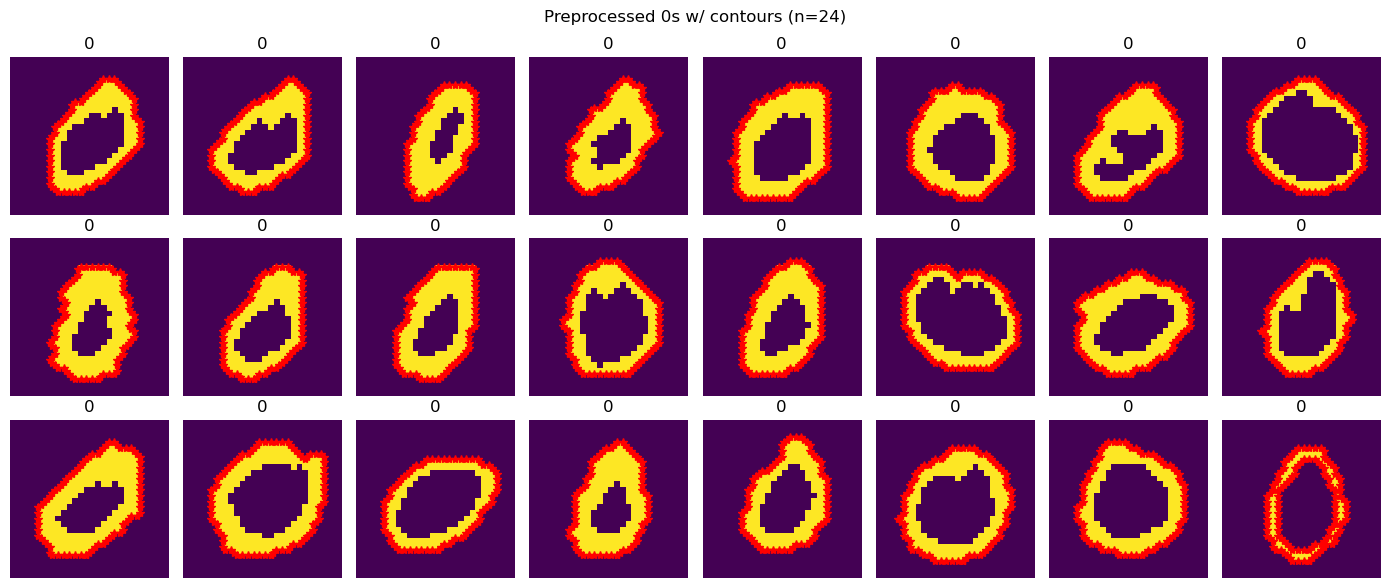

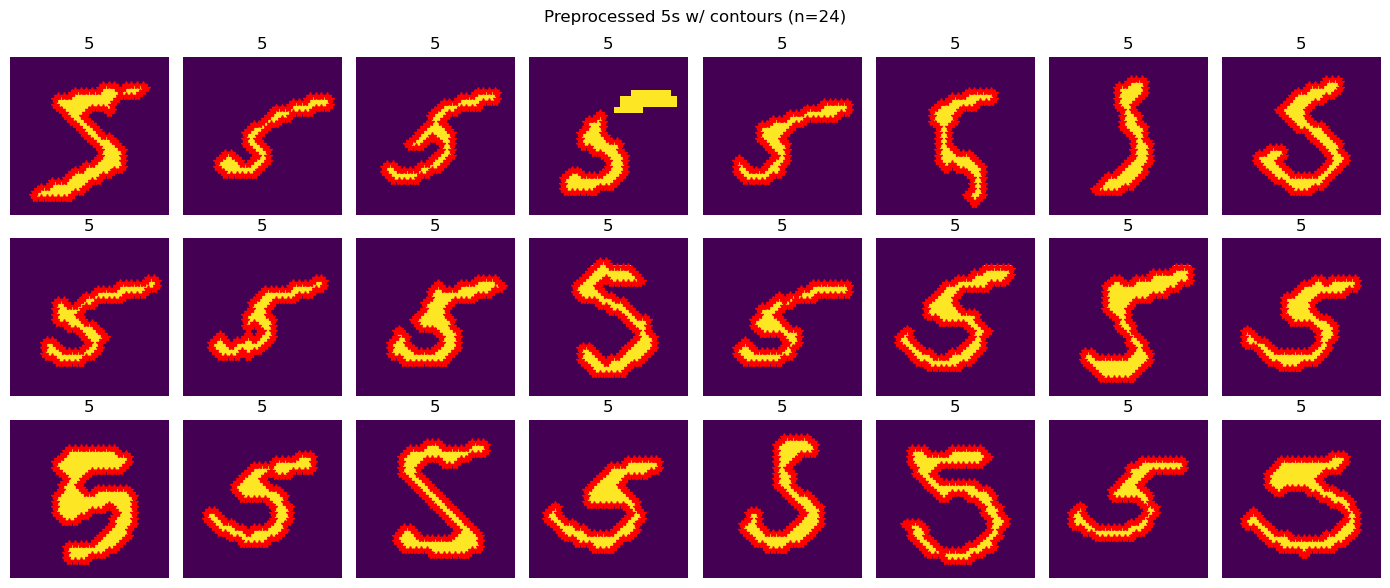

In [10]:
################################################################
############################ TEST ##############################
################################################################

cnt_p_a, cnt_p_b = test_2_1(find_contour, images_p_a, images_p_b)


Now that we are able to properly detect shape contours, we can finally compute Fourier descriptors. However, we still face a small issue. To allow a fair comparison between the Fourier descriptors we need to ensure that all descriptors have the same length.

* **Q2 (2 pts)**: Implement the function `compute_descriptor_padding` that takes as input the computed contours from before and returns the Fourier descriptors for each contour. Use `fft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)) from Numpy to compute the transformation. Use the `n_sample` argument to set the number of points to consider per contour. If the contour is longer than `n_sample` discard the extra points. If the contour is shorter than `n_sample`, use 0 paddings. Make sure that the first element of the descriptor represent the continuous component in the frequency domain.

In [11]:
def compute_descriptor_padding(contours: np.ndarray, n_samples: int = 11):
    """
    Compute Fourier descriptors of input images
    
    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    n_samples: int
        Number of samples to consider. If the contour length is higher, discard the remaining part. If it is shorter, add padding.
        Make sure that the first element of the descriptor represents the continuous component.

    Return
    ------
    descriptors: np.ndarray complex (N, n_samples)
        Computed complex Fourier descriptors for the given input images
    """

    N = len(contours)
    # Look for the number of contours
    descriptors = np.zeros((N, n_samples), dtype=np.complex128)

    # ------------------
    # Your code here ... 
    # ------------------
    for i in range(N):
        contour = contours[i]
        K = len(contour)
        complex_contour = contour[:,0] + 1j * contour[:,1]
        if K>n_samples:
            complex_contour = complex_contour[:n_samples]
        elif K<n_samples:
            complex_contour = np.pad(complex_contour, (0, n_samples - K), 'constant', constant_values = 0)

        # compute FFT
        fft_result = np.fft.fft(complex_contour)

        descriptors[i] = fft_result

    return descriptors


The code below uses the `plot_features` function to display the computed Fourier descriptors. We display the real, imaginary, and absolute components, respectively. Each color depicts a different digit. We use 2D plots to highlight the clustering capability of the components.
* **Q3 (1 pt)**: Comment on the quality of the Fourier descriptors. Do you think they are good feature descriptors? (justify)
    * **Answer**: <br>
    No, we do not think that the Fourier descriptors computed with zero-padding are good feature descriptors for this digit classification. As can be seen from the plots below, there is significant overlap between digits 0 and 5 across real, imaginary, and absolute components. There is no clear culstering or separation between the two digit classes. This occurs because zero-padding introduces artificial discontinuities at the end of each contour signal (as described in the cell below). When a contour is shorter than n_samples, the sudden transition from actual contour points to zeros creates a HF artifacts in the FT corruping frequency represenation. This makes it difficult to distinguish between shapes and the true properties.
* **Q4 (1 pt)**: Knowing that we used `n_samples=11` to compute the Fourier transform, what do the components 0, 1, 5, and 10 represent as frequencies? (high, medium, constant, etc.)
    * **Answer**: <br>
        - Component 0 is the constant/average or DC component. It represents the centroid of the contour. It has no shape information and only the position.
        - Component 1 is low frequency components. It captures global and coarse shape figures.
        - Component 5 is the medium frequency components. FFTs are symmetric so 5 represnets the highest unique frequency before the Nyquist point where it starts to mirror.
        - Component 10 is the high frequency component. This is the fine details and also where the majority of noise and artifacts lie.

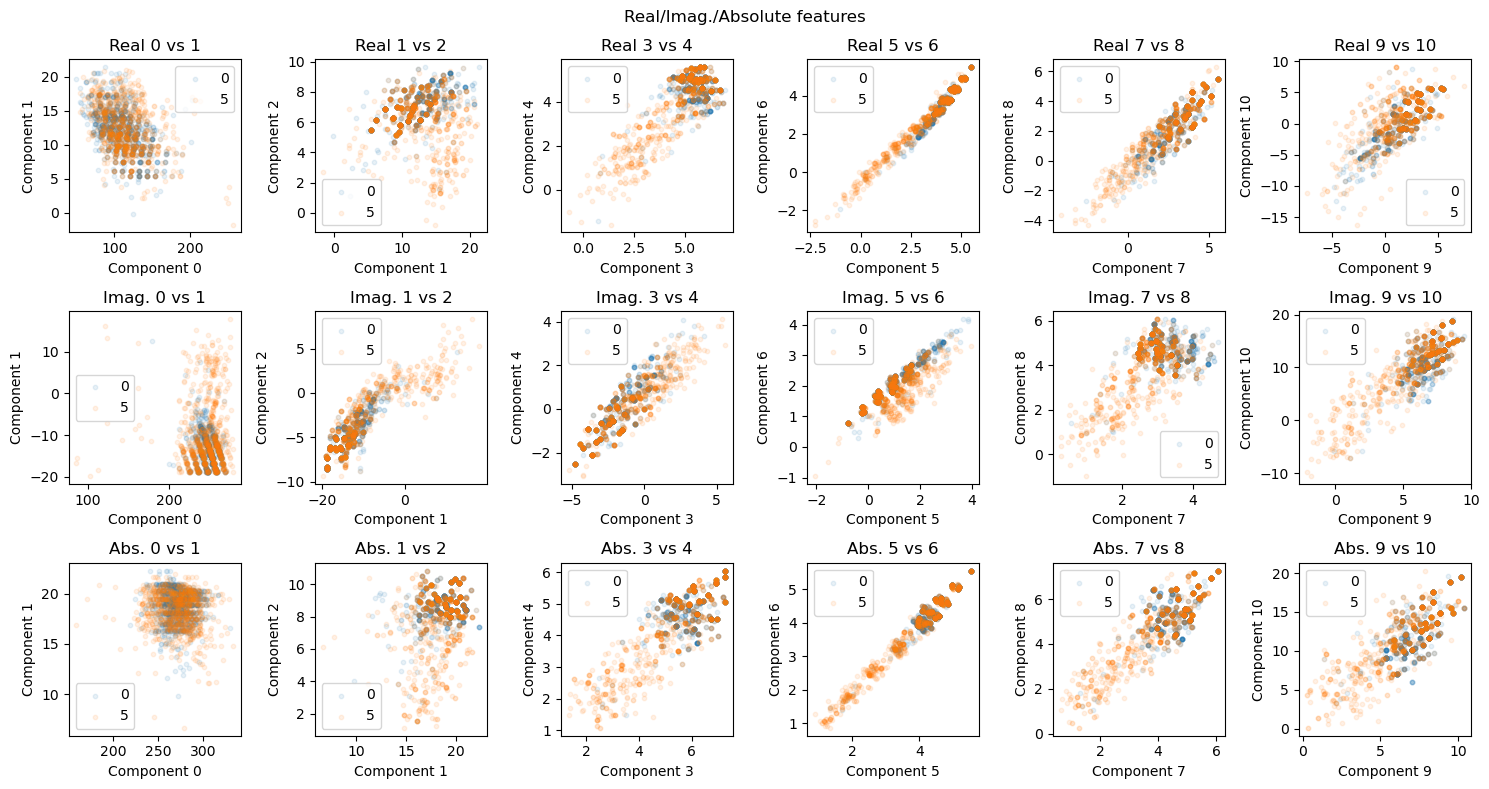

In [12]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_2(compute_descriptor_padding, cnt_p_a, cnt_p_b)

As you might have realized before, the computed Fourier descriptors do not help us to find an optimal separation between the digits. This mainly comes from the fact that using 0 padding is a cheap and inefficient way to ensure homogeneity in length for descriptors. A better solution would be to ensure that we have the same number of points along the contour for each digit. To do so, we need to implement a new function that will resample the contour such that we always have the same number of points no matter the shape.

* **Q5 (2 pts)**: Implement the function `linear_interpolation` that takes as input the contours with various lengths and the wanted number of samples per contour for resampling. For each contour, resample the points such that each contour has the same length `n_samples`. We want the points to be uniformly distributed (same distance between points) along the contour. You can use for example the function `interp` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)) from Numpy to perform the interpolation. The function `display_samples` will display the contour for different lengths.

**Hint**: Think about the contour as two distinct signals x(t) and y(t) that are evaluated at different time steps $t$. Here the time steps can be seen as the Euclidean distance between consecutive samples $t_i$ = $ \sum_{j=1}^{j \leq i} \sqrt{(x_{j} - x_{j-1})^2 + (y_{j} - y_{j-1})^2}$, and $t_0 = 0$. The aim here is to resample the function at new time steps $t_i' = i * \frac{t_{N-1}}{n_{samples} + 1}$ where $n_{samples}$ is the new number of points.

In [13]:
def linear_interpolation(contours: np.ndarray, n_samples: int = 11):
    """
    Perform interpolation/resampling of the contour across n_samples.
    
    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    n_samples: int
        Number of samples to consider along the contour.

    Return
    ------
    contours_inter: np.ndarray (N, n_samples, 2)
        Interpolated contour with n_samples
    """

    N = len(contours)
    contours_inter = np.zeros((N, n_samples, 2))
    
    # ------------------
    # Your code here ... 
    # ------------------
    for i in range(N):
        contour = contours[i]
        K=len(contour)
        x=contour[:,0]
        y=contour[:,1]

        distances = np.zeros(K)
        for j in range(1,K):
            dist = np.sqrt((x[j] - x[j-1])**2 + (y[j] - y[j-1])**2)
            distances[j] = distances[j-1] + dist

        total_len = distances[-1]

        new_dist = np.linspace(0, total_len, n_samples)
        x_interp = np.interp(new_dist, distances, x)
        y_interp = np.interp(new_dist, distances, y)

        contours_inter[i, :, 0] = x_interp
        contours_inter[i, :, 1] = y_interp

        
    return contours_inter

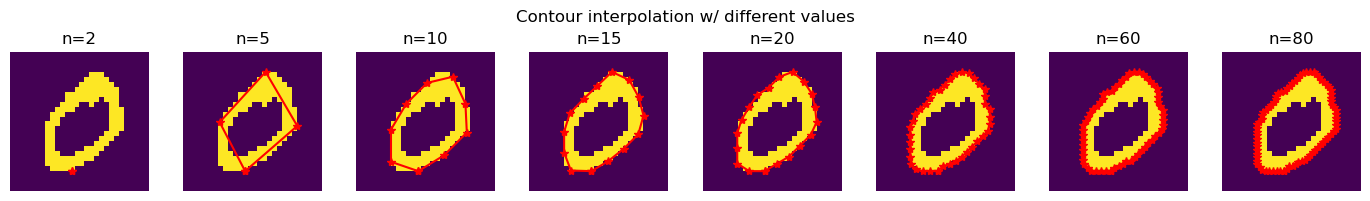

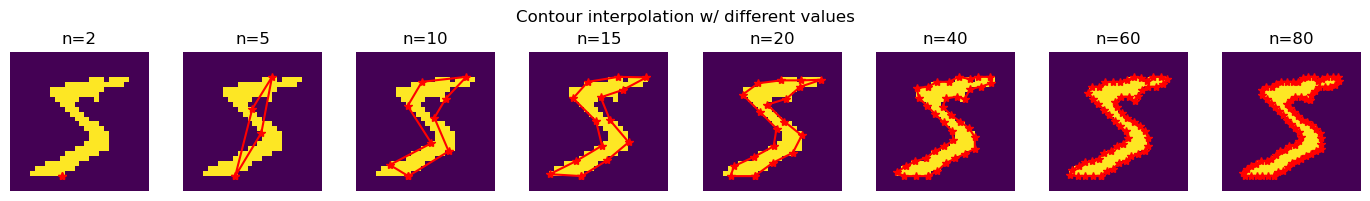

In [14]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_5(linear_interpolation, cnt_p_a, images_p_a)
test_2_1_5(linear_interpolation, cnt_p_b, images_p_b)

Now that we have implemented our resampling approach we can revisualize the clustering efficiency of our descriptors.

* **Q6 (1 pt)**: Comment on the quality of the descriptors. Is it better than before? is there a frequency/component that appears to work better? Does it make sense?
    * **Answer**: <br>
    The descriptors from resampled contours are much better than the zero-padded version. The clusters show much clearer separation between the 0 and 5 digit classes. This can be see across all 3 components (real, imaginary, and absolute). We can also see that groups are more compact and distinct, indicating that descriptors are capturing more meaningful shape information. This is due to resampling eliminating the artificial discontinuities that corrupted the zero-padded version. Resampling ensures that all contours have the same number of points sampled uniformly along their length, and intuitively this makese sense as 0 (circular shape) and 5 (curves and straight lines) should have distinctly different frequency signatures.<br>
    The imaginary and absolute components have more separated clusters than the real components. Overall the absolute component does better than the imaginary when looking at the last 3 component comparison diagrams (5vs6, 7vs8, and 9vs10). We can note that the first two diagrams of absolute (0vs1, 1vs2) have the best separation. This means that low frequencies are likely to contribute most to discrimination since the overall shape characteristics for 0 and 5 are quite different. We can also note that the abs 9 vs 10 components are also quite nicely separated as well. This is because 5's sometimes have some sharp transitions (lines meeting angles), which 0 does not have.

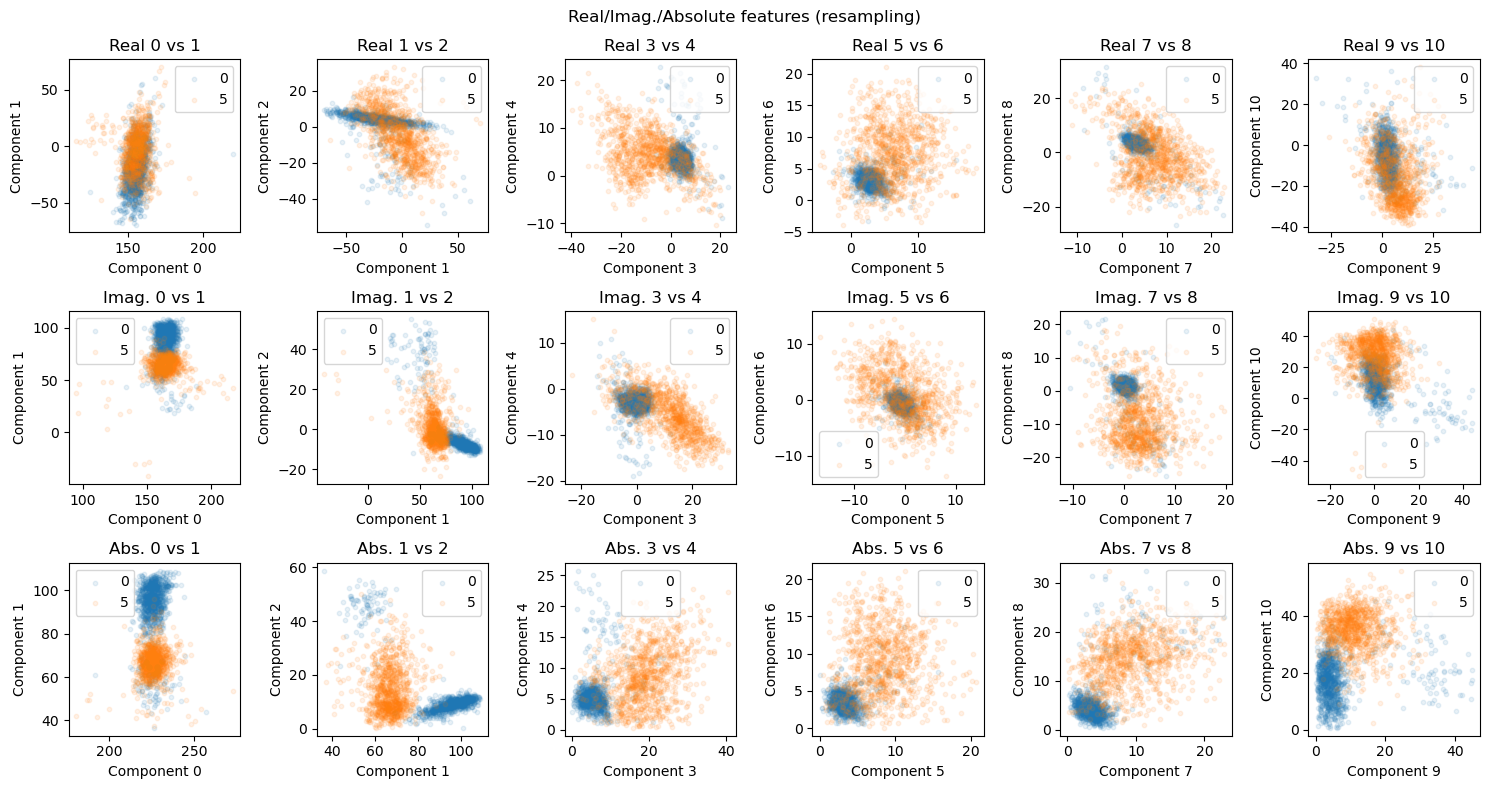

In [15]:
################################################################
############################ TEST ##############################
################################################################

feat_a, feat_b = test_2_1_6(compute_descriptor_padding, linear_interpolation, cnt_p_a, cnt_p_b, n_samples=11)

## 2.2. Reconstruction (2 pts)

For this part, we will now try to go the other way. Given a Fourier descriptor we will try to retrieve the original shape. 
* **Q1 (1 pt)** Implement the function `compute_reverse_descriptor` that takes as input a single descriptor and reverses it to x and y coordinates given a number of samples `n_samples`. Use the function `ifft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html)) from Numpy.

In [16]:
def compute_reverse_descriptor(descriptor: np.ndarray, n_samples: int = 11):
    """
    Reverse a Fourier descriptor to xy coordinates given a number of samples.
    
    Args
    ----
    descriptor: np.ndarray (D,)
        Complex descriptor of length D.
    n_samples: int
        Number of samples to consider to reverse transformation.

    Return
    ------
    x: np.ndarray complex (n_samples,)
        x coordinates of the contour
    y: np.ndarray complex (n_samples,)
        y coordinates of the contour
    """

    x = np.zeros(n_samples)
    y = np.zeros(n_samples)
    
    # ------------------
    # Your code here ... 
    # ------------------
    contour = np.fft.ifft(descriptor, n=n_samples)
    x,y = contour.real, contour.imag

    return x, y


With the function `plot_reconstruction` we plot an example of the reconstruction of the digits. We display the result as we progressively add more frequencies. We start with the first component (component 0) and then add frequency pairs from low to high frequencies.

* **Q2 (1 pt)**: Based on your observation, do you think 11 samples are enough to properly describe the digits below? (justify)
    * **Answer**: <br>
    For the '0' class, 11 samples are enough, but for '5', they are not enough; therefore in general for MNIST, 11 samples is not enough to properly describe the digits. Low frequencies capture smoother shapes, hence being conducive to the '0' class, but the '5' class has more sharp angles and details which can only be captured with higher frequencies.

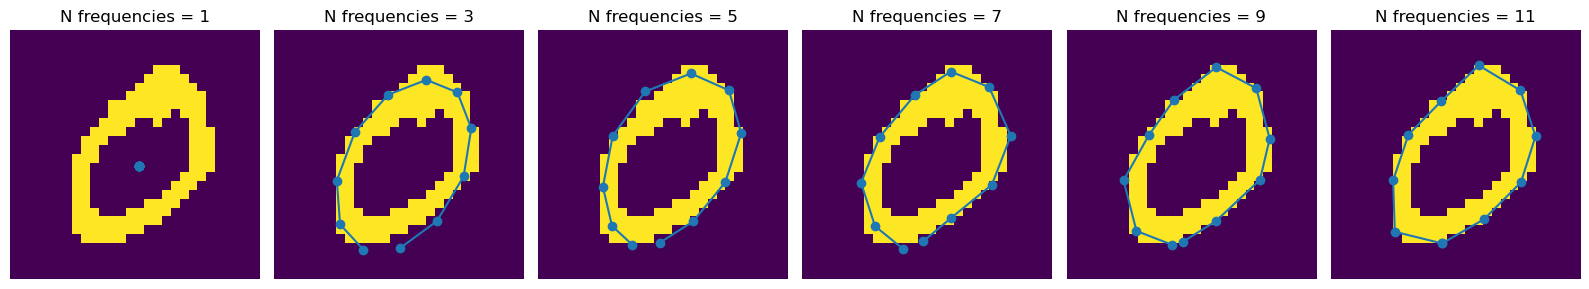

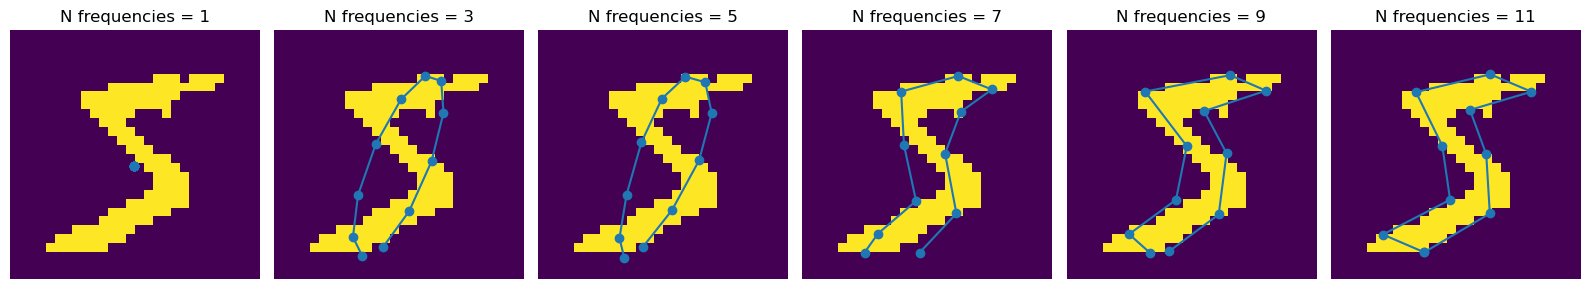

In [17]:
################################################################
############################ TEST ##############################
################################################################

test_2_2(images_p_a , images_p_b, feat_a, feat_b, compute_reverse_descriptor)

## 2.3. Invariance (6 pts)

For the last part with Fourier descriptors, we will check for descriptors invariance. As seen in class, if handled properly Fourier descriptors can be invariant to translation, rotation, and scaling.

* **Q1 (3 pts)**: Implement the functions `apply_rotation`, `apply_scaling`, and `apply_translate` to apply random rotation, scaling, and translation to input images. For scaling and translation, we recommend avoiding large values where the digits are cropped (out of frame). You can use the `random` package ([doc](https://numpy.org/doc/1.16/reference/routines.random.html)) from Numpy to generate random values.

In [18]:
def apply_rotation(img: np.ndarray):
    """
    Apply random rotation to input the image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    rotated: np.ndarray (28, 28)
        Rotated source images
    """

    rotated = np.zeros_like(img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    angle = np.random.uniform(-30, 30)
    rotated = rotate(img, angle, mode='constant', cval=0)
    
    return rotated


def apply_scaling(img: np.ndarray):
    """
    Apply random scaling to input image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    scaled: np.ndarray (28, 28)
        Scaled source images
    """
    
    scaled = np.zeros_like(img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    scale = np.random.uniform(0.7, 1.3)
    new_dim = int(28 * scale)
    scaled = resize(img, (new_dim, new_dim), mode='constant', cval=0)
    
    if new_dim <= 28:
        offset = (28 - new_dim) // 2
        scaled = np.pad(scaled, ((offset, 28 - new_dim - offset), (offset, 28 - new_dim - offset)), mode='constant', constant_values=0)
    else:
        offset = (new_dim - 28) // 2
        scaled = scaled[offset:offset+28, offset:offset+28]
    
    return scaled

def apply_translate(img: np.ndarray):
    """
    Apply random x and y translation to input image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    translated: np.ndarray (28, 28)
        Translated source images
    """
    
    translated = np.zeros_like(img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    x_shift = np.random.randint(-5, 6)
    y_shift = np.random.randint(-5, 6)

    # destination region
    x1_dst = max(0, x_shift)
    x2_dst = min(28, 28 + x_shift)
    y1_dst = max(0, y_shift)
    y2_dst = min(28, 28 + y_shift)

    # source region
    x1_src = max(0, -x_shift)
    x2_src = x1_src + (x2_dst - x1_dst)
    y1_src = max(0, -y_shift)
    y2_src = y1_src + (y2_dst - y1_dst)

    # perform translation
    translated[y1_dst:y2_dst, x1_dst:x2_dst] = img[y1_src:y2_src, x1_src:x2_src]

    return translated


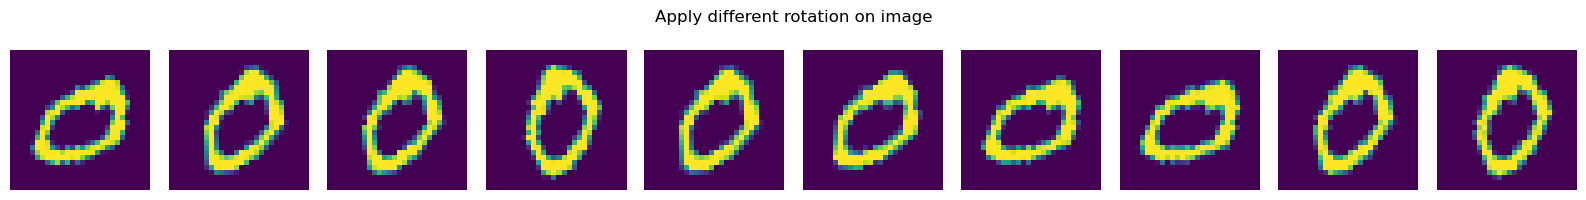

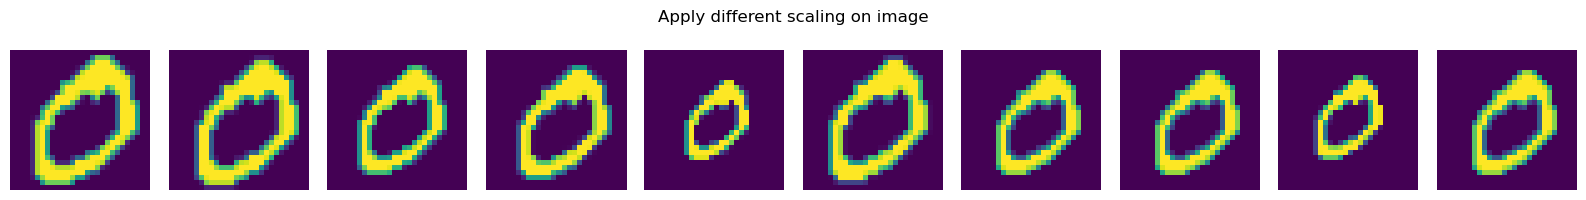

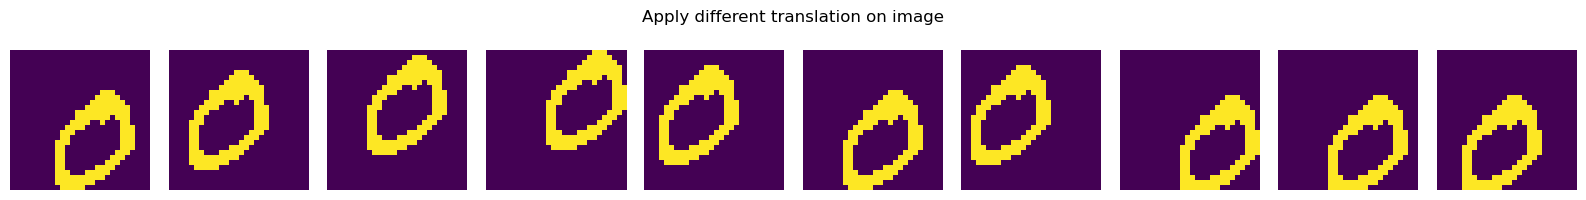

In [19]:
################################################################
############################ TEST ##############################
################################################################

test_2_3(apply_rotation, apply_scaling, apply_translate, images_p_a[0])

Now that we implemented our transformation, we can test for feature invariance. To assess the robustness of the Fourier descriptors to image transformations, we compute the error between the original descriptors (before transformation) to the one after transformation. 

* **Q2 (1 pt)**: Complet the function `translation_invariant` to make the Fourier deciptor invariant to translation. Does the error decrease after treatment for translation invariance? Is it null, if not why?
    * **Answer**: <br>
    Error decreases by a significant amount after treatment for translation invariance, but the final error still is not null. We see a significant drop because meaningless information about position is removed from descriptors, reducing intra-class variance and resulting in better class separability. However, translation is just one factor in the pipeline, so even with translation invariance, there is still error that comes from variances in other variables.

In [20]:
def translation_invariant(features):
    """
    Make input Fourier descriptors invariant to translation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to translation of N images 
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)
    
    # ------------------
    # Your code here ... 
    # ------------------
    features_inv = features[:, 1:]  # translation <=> first Fourier descriptor
    
    return features_inv

Translation error: 11.31
Corrected translation error: 8.03


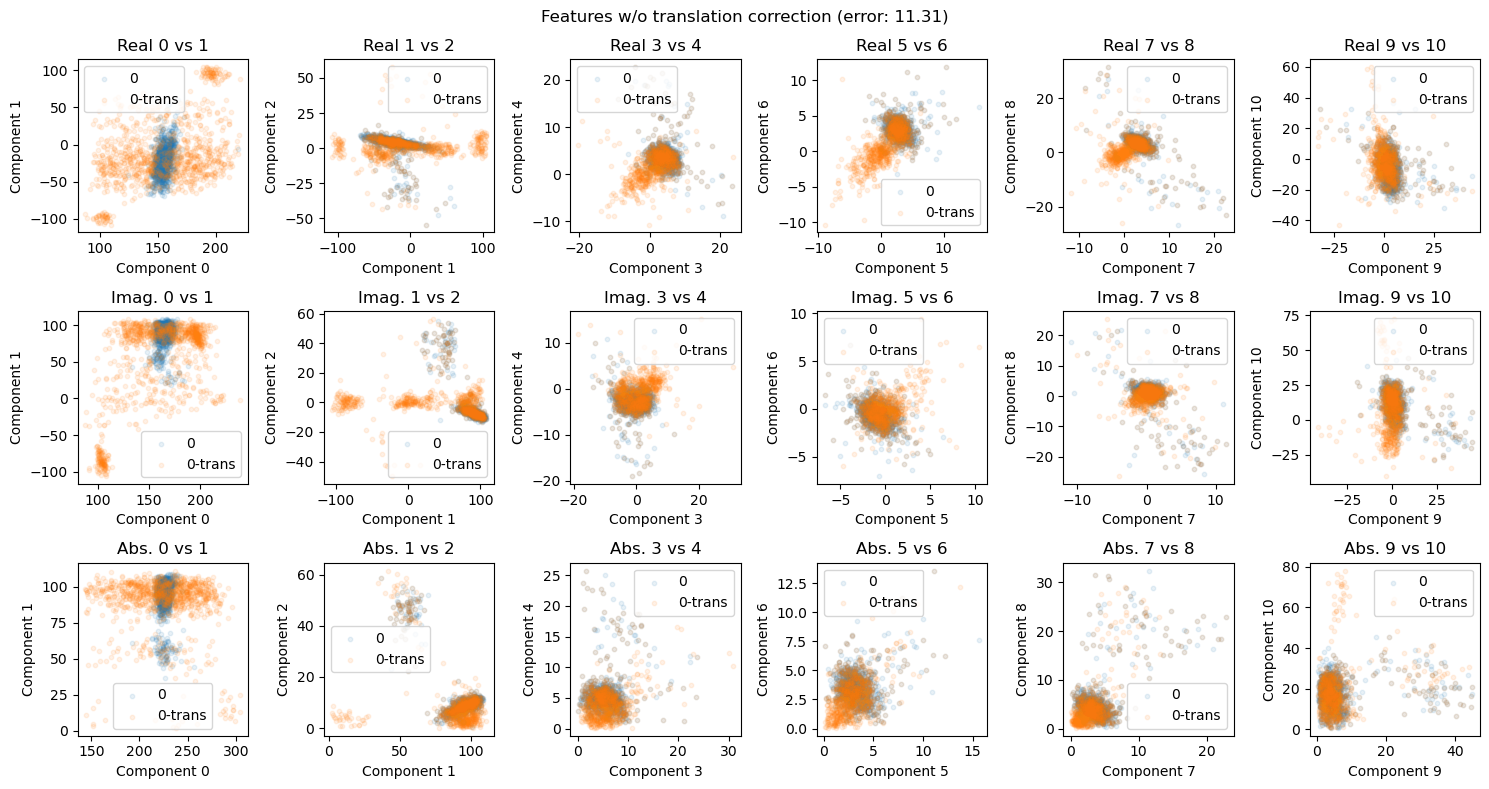

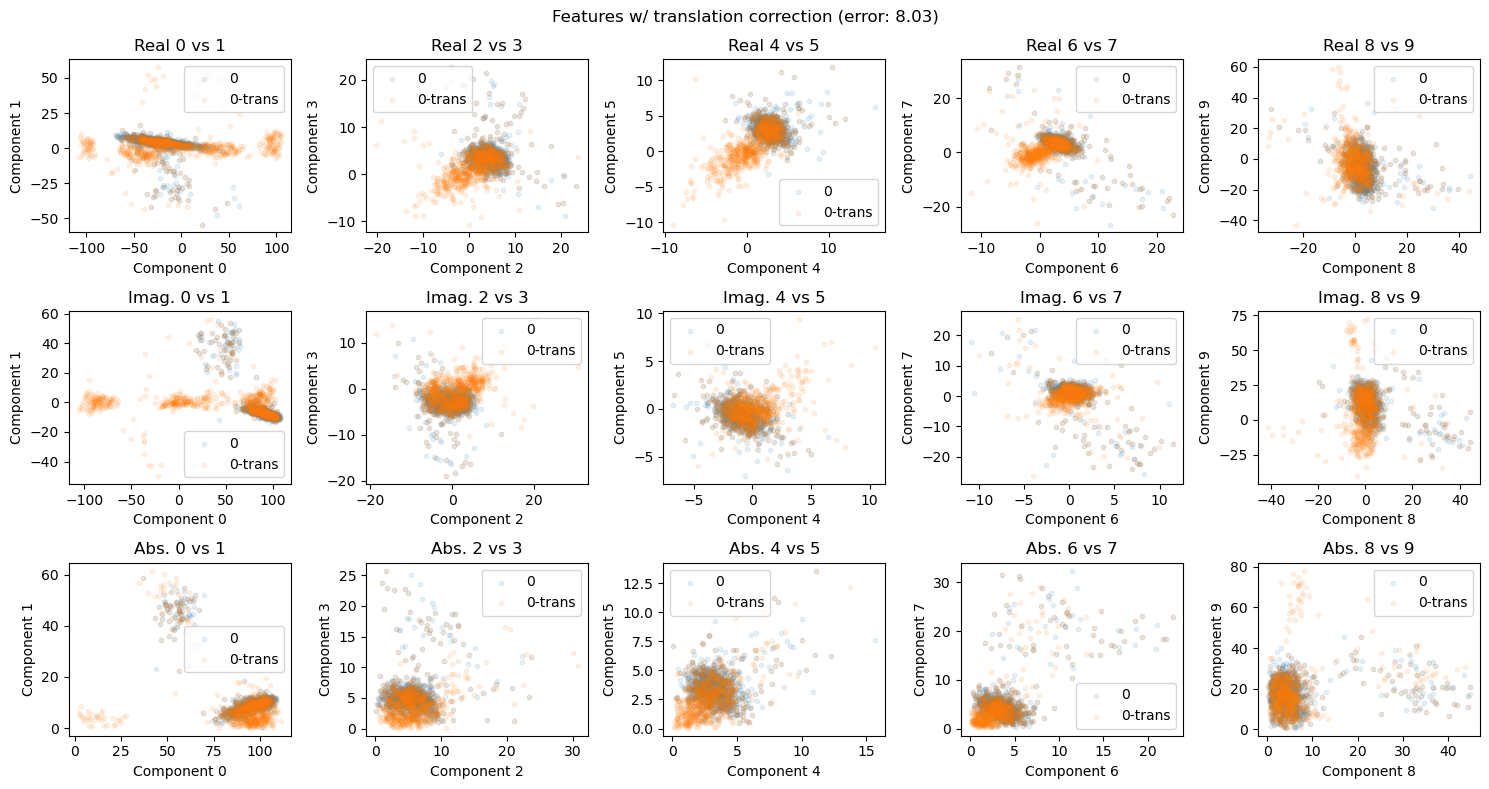

In [21]:
################################################################
############################ TEST ##############################
################################################################

feat_t_a = test_2_3_2(translation_invariant, find_contour, apply_translate, compute_descriptor_padding, linear_interpolation,images_p_a, feat_a)

* **Q3 (1 pt)**: Complet the function `rotation_invariant` to make the Fourier deciptor invariant to rotation. Does the error decrease after treatment for rotation invariance? Do you think that selecting specific rotation angles might help the error to decrease even lower?
    * **Answer**: <br>
    After treatment for rotation invariance, the error decreases slightly. This improvement is slight because we only applied rotations in a small range [-30°, 30°], hence rotation not being a large source of variance. Selecting specific rotation angles could be beneficial if the selected angles are truly representative of the rotations in the dataset. However, we also must consider that there are specific angles that will hurt performance, given that the rotational orientation of some classes is what separates them (almost) completely from other classes (e.g. '6' and '9' are mainly separated by rotational variance).

In [22]:
def rotation_invariant(features):
    """
    Make input Fourier descriptors invariant to rotation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to rotation of N images 
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)
    
    # ------------------
    # Your code here ... 
    # ------------------
    features_inv = np.abs(features)  # rotation <=> magnitude of Fourier descriptors
    

    return features_inv

Rotation error: 34.34
Corrected rotation error: 32.71


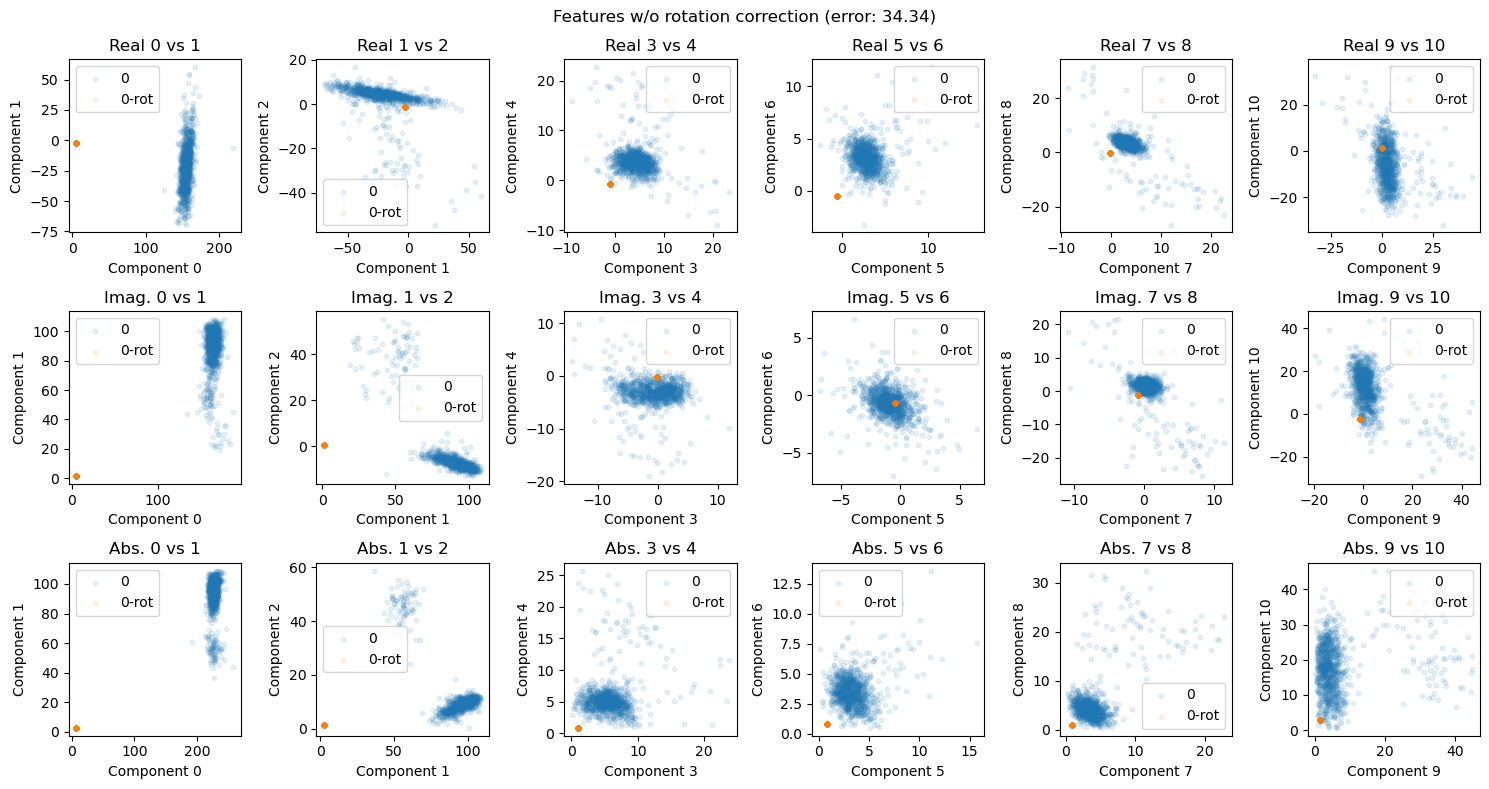

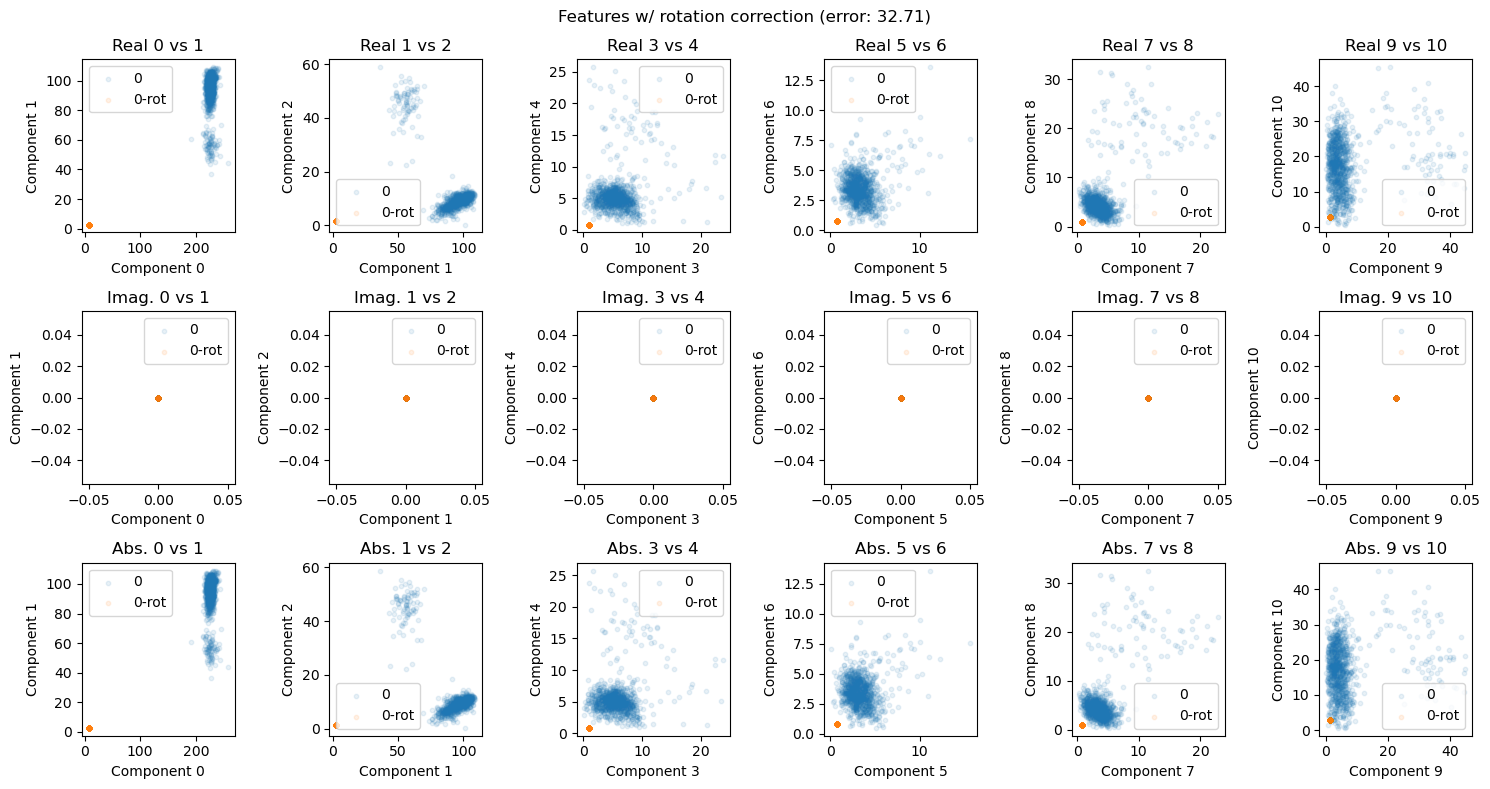

In [23]:
################################################################
############################ TEST ##############################
################################################################

test_2_3_3(rotation_invariant, find_contour, apply_rotation, compute_descriptor_padding, linear_interpolation,images_p_a, feat_a)

* **Q4 (1 pt)**: Complet the function `scaling_invariant` to make the Fourier deciptor invariant to scaling. Does the error decrease after treatment for scaling invariance? Is it null? Why?
    * **Answer**: <br>
    The scaling error decreases almost completely after normalization, the final error being effectively null. Scaling uniformly affects all Fourier components by the same factor, so dividing by the DC component magnitude recovers the original descriptor nearly perfectly. As a result, scale variability is removed and descriptors of the same digit are consistent regardless of size, resulting in near-perfect classification.

In [24]:
def scaling_invariant(features):
    """
    Make input Fourier descriptors invariant to scaling.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to scaling of N images 
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)
    
    # ------------------
    # Your code here ... 
    # ------------------
    # normalize by first descriptor
    norms = np.abs(features[:,0]) 
    features_inv = features / norms[:, None]  

    return features_inv

Scaling error: 34.34
Corrected scaling error: 0.17


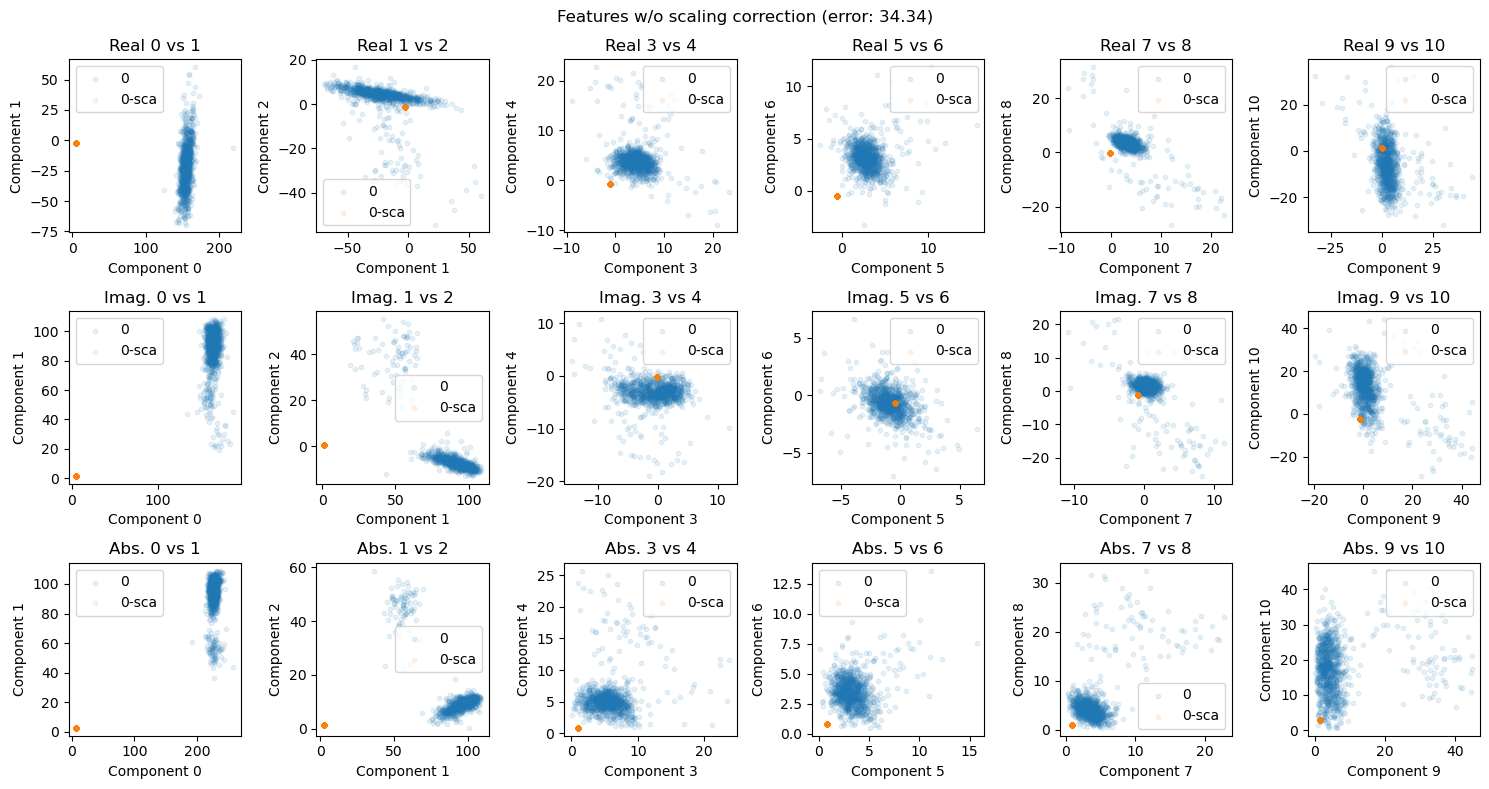

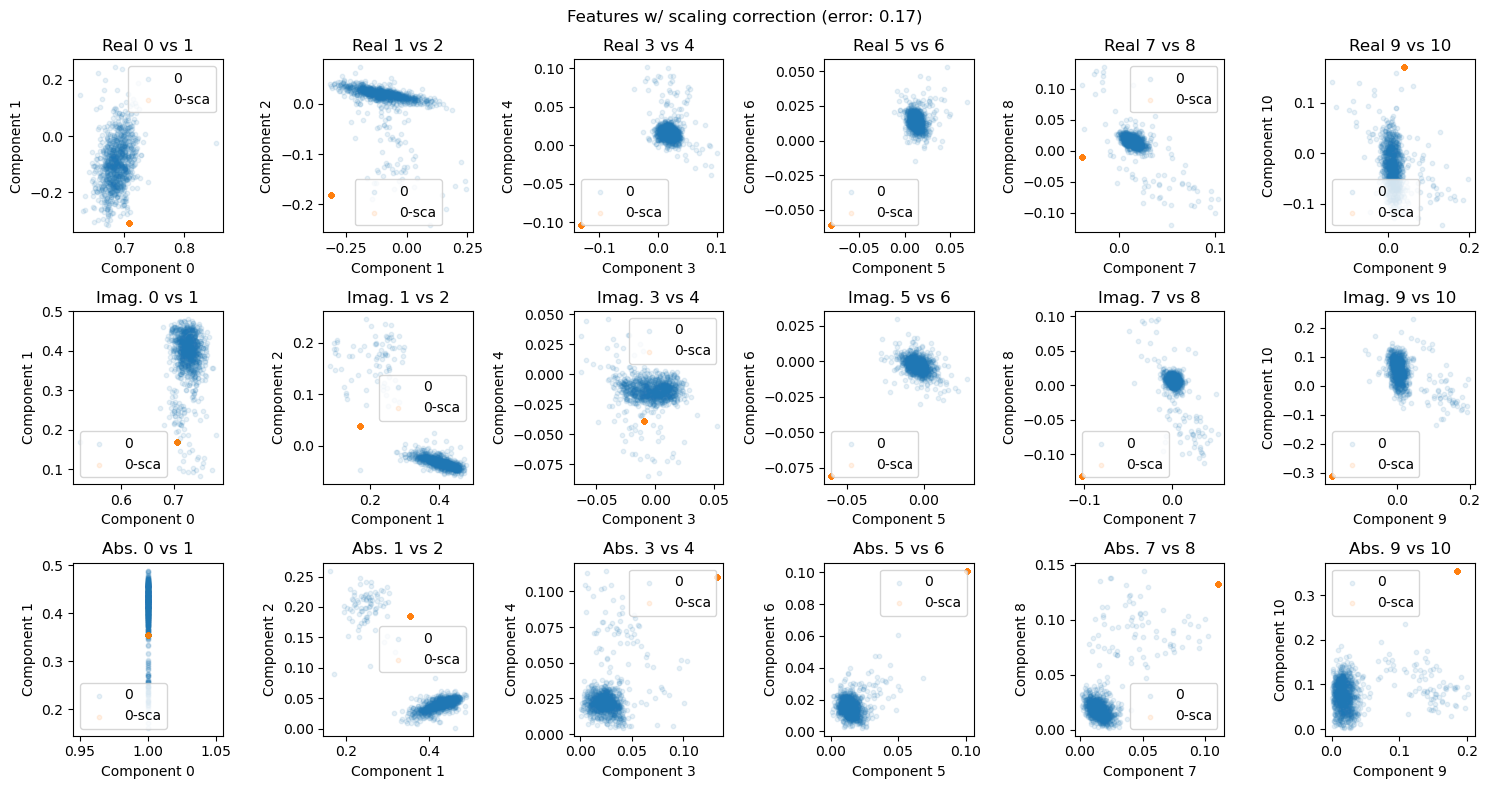

In [25]:
################################################################
############################ TEST ##############################
################################################################
test_2_3_4(scaling_invariant, find_contour, apply_scaling, compute_descriptor_padding, linear_interpolation, images_p_a, feat_a)

---
# PART 3 - Other descriptors [8 pts]

## 3.1 Distance map (5 pts)

In this part, we will learn how to use a distance map as a feature descriptor. 

* **Q1 (1 pt)**: To compute a distance map we first need a reference pattern. Complete the function `reference_pattern`. The function takes as input a list of images and computes the reference pattern as the average of all shapes.

In [7]:
def reference_pattern(imgs):
    """
    Compute the reference pattern for a given set of images. The reference pattern 
    is estimated as the average of all images of the same pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
        
    Return
    ------
    pattern: np.ndarray (28, 28)
        Thresholded reference pattern that is the average of all shapes.
    """

    # Initialize pattern
    pattern = np.zeros((imgs[0].shape[0], imgs[0].shape[1]))
    
    # ------------------
    # Your code here ... 
    # ------------------
    avg_pattern = np.mean(imgs, axis=0) # computing avg of all N images

    pattern = (avg_pattern > 0.3).astype(np.uint8) # the threshold is an input value we can change to better the algorthm recognition
    # 0.5 gave unrecognisable result, 0.4 better, but the most recognisable is 0.3 at the 5
    
   
    return pattern

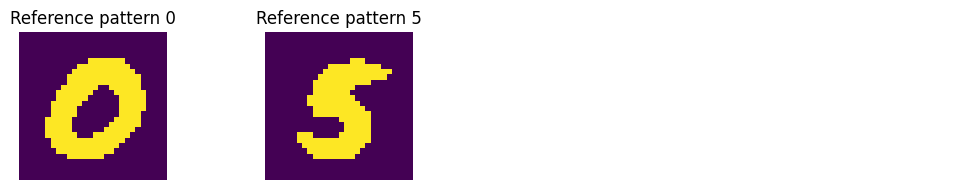

In [8]:
################################################################
############################ TEST ##############################
################################################################

pattern_a, pattern_b = test_3_1(reference_pattern, images_p_a, images_p_b)

* **Q2 (2 pts)**: The next part will be to compute a distance map from the generated pattern. By pre-computing the distance map we can speedup the inference time. Complete the function `compute_distance_map`. We expect the values of the map to represent the distances to the closest pattern contour. If needed, can take advantage of the functions you wrote in PART2 to detect and resample contours.

In [9]:
def compute_distance_map(pattern: np.ndarray):
    """
    Compute the distance map for the given pattern. The values of the map are computed as 
    the distance to the closest pattern contour.

    Args
    ----
    pattern: np.ndarray (28, 28)
        Pattern to process

    Return
    ------
    distance_map: np.ndarray (28, 28)
        Distance map where each entry is the distance to the closest pattern contour (shortest 
        distance to pattern)
    """
    
    # Initialize dummy values
    distance_map = np.zeros_like(pattern)
    
    # ------------------
    # Your code here ... 
    # ------------------
    pattern = pattern.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8) 
    eroded_pattern = cv2.erode(pattern, kernel, iterations=1)
    contour = pattern - eroded_pattern
    background = (contour == 0).astype(np.uint8) # distance_transform_edt calculates the distance from every true (1) pixel to the nearest 
                                                 # false (0) pixel. 
                                                 # contour mask will be 0, everuthing else 1
    distance_map = cv2.distanceTransform(background, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    
    return distance_map


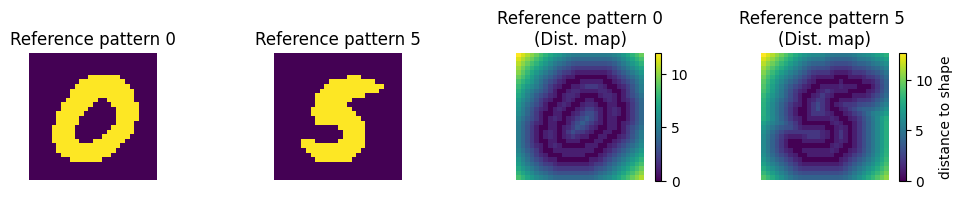

In [10]:
################################################################
############################ TEST ##############################
################################################################

map_a, map_b = test_3_1_2(compute_distance_map, pattern_a, pattern_b)

* **Q3 (2 pts)**: For the last part, implement the function `compute_distance` that uses the precomputed distance map to evaluate the distance to all images. Note that for each image you should return the average of distances. As before, for each digit, you can compute the contour and estimate the point-to-point distance by evaluating the distance map at the xy contour coordinates.

In [ ]:
def compute_distance(imgs, d_map):
    """
    Compute the distances for each image with respect to the reference pattern using the precomputed 
    distance map. The final distance is the average of all distances from the image's contour points 
    to the reference pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
    d_map: np.ndarray (28, 28)
        The precomputed distance map where each entry is the distance to the closest pattern contour 
        (shortest distance to pattern)
    
    Return
    ------
    dist: np.ndarray (N, )
        Averaged distance to pattern for each input image.
    """
    
    # Default values
    dist = np.zeros(len(imgs))

    # ------------------
    # Your code here ... 
    # ------------------
    kernel = np.ones((3, 3), np.uint8)

    for i in range(len(imgs)):
        img = imgs[i]
        
        binary_img = (img > 0.3).astype(np.uint8)
        
        eroded_img = cv2.erode(binary_img, kernel, iterations=1)
        contour = binary_img - eroded_img
        
        dist[i] = np.mean(d_map[contour == 1])
    
    return dist

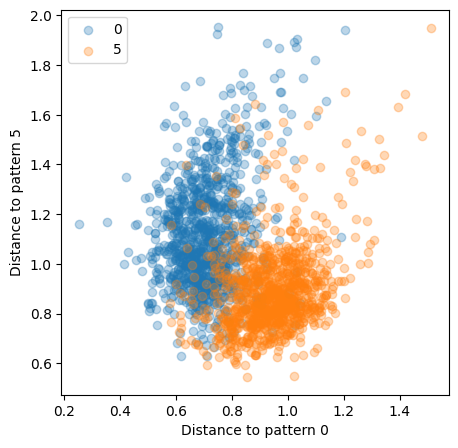

In [12]:
################################################################
############################ TEST ##############################
################################################################

test_3_1_3(compute_distance, images_p_a, images_p_b, map_a, map_b)

## 3.2 Others (3 pts)

For the last part of the lab, we will compute other various visual features. 

* **Q1: (2 pts)**: Implement the function `compute_features` that estimates the digit's perimeter, area, compacity, and rectangularity. You can use the lecture to look for the definition of each feature. To help you with this task we strongly recommend using the `regionprops` ([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops)) from scikit-image.
* **Q2: (1 pt)**: Which feature(s) seem(s) to show the best results to distinguish between both digits? (justify)
    * **Answer**: <br>
    The first plot has a big overlap since perimeter and area are tied to the size of the handwriting, i.e. a giant 5 will show much larger than a tiny 0. The second plot is showing distinct clusters, mainly separated vertically along the y-axis, showing that we are measuring shape proportions regardless of the size of the digit drawing. Thus, Rectangularity (and to a slightly lesser extent, Compacity) show the best results for distinguishing between a '0' and a '5'. It is scale irrelevant, unlike Perimeter and Area, providing the cleanest separation in the plot: '0' is roughly elliptical and fills a large, consistent percentage of its bounding box, while '5' is an open, squiggly shape with significant empty space (indentations and gaps), meaning it fills a much smaller percentage of its bounding box. Compacity penalizes complex, winding shapes. Because a '0' is a simple closed loop, it has a lower perimeter-to-area ratio. A '5' is a long, complex stroke, resulting in a higher perimeter relative to its area.

In [13]:
def compute_features(imgs: np.ndarray):
    """
    Compute compacity for each input image.
    
    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
        
    Return
    ------
    f_peri: np.ndarray (N,)
        Estimated perimeter length for each image
    f_area: np.ndarray (N,)
        Estimated area for each image
    f_comp: np.ndarray (N,)
        Estimated compacity for each image
    f_rect: np.ndarray (N,)
        Estimated rectangularity for each image
    """

    f_peri = np.zeros(len(imgs))
    f_area = np.zeros(len(imgs))
    f_comp = np.zeros(len(imgs))
    f_rect = np.zeros(len(imgs))
    
    # ------------------
    # Your code here ... 
    # ------------------

    for i in range(len(imgs)):
        
        binary_img = (imgs[i] > 0.3).astype(np.uint8)
        
        props = regionprops(binary_img) 
        
        if len(props) > 0:
            region = props[0]
            
            f_area[i] = region.area # total number of pixels in region
            
            f_peri[i] = region.perimeter # length of outside boundary
            
            if region.area > 0:
                f_comp[i] = (region.perimeter ** 2) / region.area # standard formula used: (perimeter^2) / area
                
            f_rect[i] = region.extent # how well it fills the bounding box

    return f_peri, f_area, f_comp, f_rect


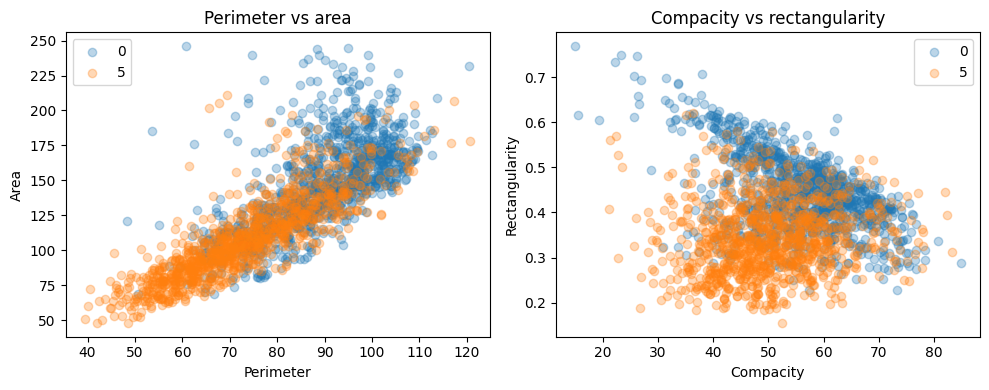

In [14]:
################################################################
############################ TEST ##############################
################################################################

test_3_2(compute_features, images_p_a, images_p_b)